
# SF3 Week 3.1 — Action-conditioned dynamics model

This notebook starts the **control** part of the project, but it deliberately does **not** optimise a policy yet.  The aim is to close the modelling-to-control transition cleanly:

$$
X = [x, \dot{x}, \theta, \dot{\theta}]
\quad \longrightarrow \quad
[X,u] = [x, \dot{x}, \theta, \dot{\theta}, u]
$$

where `u` is the scalar action passed to `CartPole.performAction(action)`.

## Week 1–2 close-out for the final report

For the final report, Week 1–2 should now be treated as **supporting evidence**, not as the main remaining workload.  The useful material to keep is:

1. A compact explanation of **one-step prediction vs recursive rollout**.
2. One readable figure/table showing **component-wise MSE** and **N/M selection**.
3. One rollout figure showing the **sin/cos kernel model's short-horizon usefulness**.
4. A concise explanation of why raw angle features fail and why \(\sin\theta,\cos\theta\) help.

This notebook begins Week 3 Task 3.1 and produces the evidence needed to answer:

> What are the maximum and minimum actions/forces that can be applied while the learned dynamics model still makes accurate one-step and rollout predictions?



## 0. Imports and run mode

Use `RUN_MODE = "quick"` first.  After the notebook runs once and the plots look sensible, change it to `"full"` for final-report-quality numbers.

The notebook writes all outputs to:

```text
sf3_week3_task31_action_model/
├── data/
├── figures/
└── logs/
```


In [3]:

from __future__ import annotations

import json
import math
import os
import sys
from pathlib import Path
from typing import Dict, Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartpole import CartPole, remap_angle

# -------------------------
# Main switch
# -------------------------
RUN_MODE = "full"   # change to "full" after the notebook runs successfully
SEED = 492

# Output folders
OUT = Path("sf3_week3_task31_action_model")
DATA_DIR = OUT / "data"
FIG_DIR = OUT / "figures"
LOG_DIR = OUT / "logs"
for d in [OUT, DATA_DIR, FIG_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(SEED)

if RUN_MODE == "quick":
    N_TRAIN, N_VAL, N_TEST = 450, 150, 150
    M_CENTRES = 80
    ACTION_LIMIT_CANDIDATES = [5.0, 10.0, 20.0, 40.0]
    SELECTED_ACTION_LIMIT = 20.0
    GRID_N = 25
    ROLLOUT_HORIZON = 60
    BIN_N = 120
    KERNEL_LENGTHSCALE = 5.0
    KERNEL_LAMBDA = 1e-4
else:
    N_TRAIN, N_VAL, N_TEST = 1800, 500, 500
    M_CENTRES = 160
    ACTION_LIMIT_CANDIDATES = [2.0, 5.0, 10.0, 20.0, 40.0]
    SELECTED_ACTION_LIMIT = 20.0
    GRID_N = 45
    ROLLOUT_HORIZON = 100
    BIN_N = 400
    KERNEL_LENGTHSCALE = 5.0
    KERNEL_LAMBDA = 1e-4

CONFIG = {
    "run_mode": RUN_MODE,
    "seed": SEED,
    "n_train": N_TRAIN,
    "n_val": N_VAL,
    "n_test": N_TEST,
    "m_centres": M_CENTRES,
    "action_limit_candidates": ACTION_LIMIT_CANDIDATES,
    "selected_action_limit": SELECTED_ACTION_LIMIT,
    "grid_n": GRID_N,
    "rollout_horizon": ROLLOUT_HORIZON,
    "kernel_lengthscale": KERNEL_LENGTHSCALE,
    "kernel_lambda": KERNEL_LAMBDA,
}
with open(LOG_DIR / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

print(json.dumps(CONFIG, indent=2))


{
  "run_mode": "full",
  "seed": 492,
  "n_train": 1800,
  "n_val": 500,
  "n_test": 500,
  "m_centres": 160,
  "action_limit_candidates": [
    2.0,
    5.0,
    10.0,
    20.0,
    40.0
  ],
  "selected_action_limit": 20.0,
  "grid_n": 45,
  "rollout_horizon": 100,
  "kernel_lengthscale": 5.0,
  "kernel_lambda": 0.0001
}



## 1. Simulator helpers

The action passed into `performAction(action)` is a **commanded action**, not exactly the physical force.  The CartPole code maps it through

$$
F(u) = F_{\max}\tanh(u/F_{\max}).
$$

Therefore large values of `u` saturate near \(F_{\max}\).  The table printed below is useful in the report because it translates the action limits used for data collection into effective force limits.


In [5]:

def effective_force(action: np.ndarray | float, max_force: float = 20.0) -> np.ndarray | float:
    """Physical force after the tanh saturation used in cartpole.py."""
    return max_force * np.tanh(np.asarray(action) / max_force)


def periodic_angle_error(theta_pred: np.ndarray, theta_true: np.ndarray) -> np.ndarray:
    """Smallest signed angle error theta_pred - theta_true in [-pi, pi]."""
    return (theta_pred - theta_true + np.pi) % (2 * np.pi) - np.pi


def one_step_delta(state: np.ndarray, action: float) -> np.ndarray:
    """Return X(t+1) - X(t) after one CartPole.performAction(action)."""
    system = CartPole(visual=False)
    system.setState(np.asarray(state, dtype=float).copy())
    x0 = system.getState().copy()
    system.performAction(float(action))
    x1 = system.getState().copy()
    return x1 - x0


def one_step_next(state: np.ndarray, action: float) -> np.ndarray:
    """Return X(t+1)."""
    return np.asarray(state, dtype=float) + one_step_delta(state, action)


force_table = pd.DataFrame({
    "action_limit_u": ACTION_LIMIT_CANDIDATES,
    "effective_force_at_+u": [float(effective_force(a)) for a in ACTION_LIMIT_CANDIDATES],
    "effective_force_at_-u": [float(effective_force(-a)) for a in ACTION_LIMIT_CANDIDATES],
    "fraction_of_max_force": [float(abs(effective_force(a)) / 20.0) for a in ACTION_LIMIT_CANDIDATES],
})
display(force_table)
force_table.to_csv(LOG_DIR / "action_limit_to_effective_force.csv", index=False)


,action_limit_u,effective_force_at_+u,effective_force_at_-u,fraction_of_max_force
0,2.0,1.993360,-1.993360,0.099668
1,5.0,4.898373,-4.898373,0.244919
2,10.0,9.242343,-9.242343,0.462117
3,20.0,15.231883,-15.231883,0.761594
4,40.0,19.280552,-19.280552,0.964028



## 2. Data collection: random state plus random action

For Task 3.1, each training example is:

$$
\left([x, \dot{x}, \theta, \dot{\theta}, u],\; \Delta X\right),
\quad
\Delta X = X(t+1) - X(t).
$$

The state ranges are the same broad ranges used in Week 1–2.  Actions are sampled uniformly from \([-u_{\max}, u_{\max}]\).


In [7]:

STATE_RANGES = np.array([
    [-5.0, 5.0],             # x
    [-10.0, 10.0],           # x_dot
    [-np.pi, np.pi],         # theta
    [-15.0, 15.0],           # theta_dot
], dtype=float)

STATE_NAMES = ["x", "x_dot", "theta", "theta_dot"]
DELTA_NAMES = ["delta_x", "delta_x_dot", "delta_theta", "delta_theta_dot"]


def sample_states(n: int, rng: np.random.Generator) -> np.ndarray:
    lo, hi = STATE_RANGES[:, 0], STATE_RANGES[:, 1]
    return rng.uniform(lo, hi, size=(n, 4))


def sample_dataset(n: int, action_limit: float, rng: np.random.Generator) -> Tuple[np.ndarray, np.ndarray]:
    """Return X5=[state, action] and Y=delta_state."""
    states = sample_states(n, rng)
    actions = rng.uniform(-action_limit, action_limit, size=n)
    X5 = np.column_stack([states, actions])
    Y = np.empty((n, 4), dtype=float)
    for i in range(n):
        Y[i] = one_step_delta(states[i], actions[i])
    return X5, Y


# Small smoke test
X5_smoke, Y_smoke = sample_dataset(3, 5.0, rng)
print("X5 shape:", X5_smoke.shape, "Y shape:", Y_smoke.shape)
print("Example [x, x_dot, theta, theta_dot, action] -> delta:")
print(np.round(np.column_stack([X5_smoke, Y_smoke]), 4))


X5 shape: (3, 5) Y shape: (3, 4)
Example [x, x_dot, theta, theta_dot, action] -> delta:
[[ 0.8876  5.1736  0.3723 -3.0846  4.4909  0.5473  0.6165 -0.3554 -1.1906]
 [ 3.6712  6.7921  1.5015  8.1187 -1.8105  0.7266  1.081   0.9913  3.9638]
 [-1.3836  6.0539  1.2219 12.2393 -2.6067  0.7008  2.0777  1.3981  4.6327]]



## 3. Feature representation

The original input has five physical variables, but as in Week 2.3 we replace the raw angle by both sine and cosine:

$$
\phi(X,u) = [x, \dot{x}, \sin\theta, \cos\theta, \dot\theta, u].
$$

This keeps the periodic geometry visible to the model.  The features are then standardised using the training-set mean and standard deviation before fitting either the affine baseline or the sparse Gaussian-kernel model.


In [9]:

def sincos_action_features(X5: np.ndarray) -> np.ndarray:
    """Map [x, x_dot, theta, theta_dot, action] -> [x, x_dot, sin(theta), cos(theta), theta_dot, action]."""
    X5 = np.asarray(X5, dtype=float)
    return np.column_stack([
        X5[:, 0],
        X5[:, 1],
        np.sin(X5[:, 2]),
        np.cos(X5[:, 2]),
        X5[:, 3],
        X5[:, 4],
    ])


class Standardiser:
    def __init__(self, mean: np.ndarray, std: np.ndarray):
        self.mean = np.asarray(mean, dtype=float)
        self.std = np.asarray(std, dtype=float)
        self.std[self.std < 1e-12] = 1.0

    @classmethod
    def fit(cls, X: np.ndarray) -> "Standardiser":
        return cls(np.mean(X, axis=0), np.std(X, axis=0))

    def transform(self, X: np.ndarray) -> np.ndarray:
        return (np.asarray(X, dtype=float) - self.mean) / self.std


feat_smoke = sincos_action_features(X5_smoke)
print("Feature shape after sin/cos mapping:", feat_smoke.shape)
print(np.round(feat_smoke, 4))


Feature shape after sin/cos mapping: (3, 6)
[[ 0.8876  5.1736  0.3637  0.9315 -3.0846  4.4909]
 [ 3.6712  6.7921  0.9976  0.0693  8.1187 -1.8105]
 [-1.3836  6.0539  0.9397  0.3419 12.2393 -2.6067]]



## 4. Models

Two models are fitted for comparison:

### Affine baseline

$$
\Delta X \approx W^T[\phi(X,u),1].
$$

### Sparse Gaussian-kernel model

$$
f(z) = K_{NM}\alpha_M,
$$

with centres chosen from the training set.  For numerical stability the sparse normal equation is solved as

$$
\alpha_M = (K_{MN}K_{NM} + \lambda K_{MM} + \epsilon I)^{-1}K_{MN}Y_N.
$$

The code uses `np.linalg.solve`, not an explicit matrix inverse.


In [11]:

def add_intercept(Phi: np.ndarray) -> np.ndarray:
    return np.column_stack([Phi, np.ones(Phi.shape[0])])


class AffineDeltaModel:
    def __init__(self, feature_standardiser: Standardiser, coef: np.ndarray, y_scale: np.ndarray):
        self.feature_standardiser = feature_standardiser
        self.coef = coef
        self.y_scale = y_scale

    @classmethod
    def fit(cls, X5_train: np.ndarray, Y_train: np.ndarray) -> "AffineDeltaModel":
        Phi = sincos_action_features(X5_train)
        fs = Standardiser.fit(Phi)
        Phi_s = fs.transform(Phi)
        A = add_intercept(Phi_s)
        coef, *_ = np.linalg.lstsq(A, Y_train, rcond=None)
        y_scale = np.std(Y_train, axis=0)
        y_scale[y_scale < 1e-12] = 1.0
        return cls(fs, coef, y_scale)

    def predict_delta(self, X5: np.ndarray) -> np.ndarray:
        Phi = sincos_action_features(X5)
        Phi_s = self.feature_standardiser.transform(Phi)
        return add_intercept(Phi_s) @ self.coef



def rbf_kernel(A: np.ndarray, B: np.ndarray, lengthscale: float | np.ndarray = 1.0) -> np.ndarray:
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    ell = np.asarray(lengthscale, dtype=float)
    diff = (A[:, None, :] - B[None, :, :]) / ell
    return np.exp(-0.5 * np.sum(diff * diff, axis=2))


class SparseKernelDeltaModel:
    def __init__(self, feature_standardiser: Standardiser, centres: np.ndarray, alpha: np.ndarray, lam: float, y_scale: np.ndarray, lengthscale: float | np.ndarray):
        self.feature_standardiser = feature_standardiser
        self.centres = centres
        self.alpha = alpha
        self.lam = lam
        self.y_scale = y_scale
        self.lengthscale = lengthscale

    @classmethod
    def fit(
        cls,
        X5_train: np.ndarray,
        Y_train: np.ndarray,
        m_centres: int,
        rng: np.random.Generator,
        lengthscale: float | np.ndarray = 5.0,
        lam: float = 1e-4,
        jitter: float = 1e-8,
    ) -> "SparseKernelDeltaModel":
        Phi = sincos_action_features(X5_train)
        fs = Standardiser.fit(Phi)
        Phi_s = fs.transform(Phi)
        n = Phi_s.shape[0]
        m = min(m_centres, n)
        centre_idx = rng.choice(n, size=m, replace=False)
        Z = Phi_s[centre_idx]

        K_NM = rbf_kernel(Phi_s, Z, lengthscale)       # N x M
        K_MN = K_NM.T                              # M x N
        K_MM = rbf_kernel(Z, Z, lengthscale)       # M x M

        assert K_NM.shape == (n, m)
        assert K_MN.shape == (m, n)
        assert K_MM.shape == (m, m)

        A = K_MN @ K_NM + lam * K_MM + jitter * np.eye(m)
        B = K_MN @ Y_train
        try:
            alpha = np.linalg.solve(A, B)
        except np.linalg.LinAlgError:
            alpha, *_ = np.linalg.lstsq(A, B, rcond=None)

        y_scale = np.std(Y_train, axis=0)
        y_scale[y_scale < 1e-12] = 1.0
        return cls(fs, Z, alpha, lam, y_scale, lengthscale)

    def predict_delta(self, X5: np.ndarray) -> np.ndarray:
        Phi = sincos_action_features(X5)
        Phi_s = self.feature_standardiser.transform(Phi)
        K = rbf_kernel(Phi_s, self.centres, self.lengthscale)
        return K @ self.alpha



def evaluate_model(model, X5: np.ndarray, Y: np.ndarray, label: str) -> Dict[str, float]:
    pred = model.predict_delta(X5)
    err = pred - Y
    raw_component_mse = np.mean(err**2, axis=0)
    std_component_mse = np.mean((err / model.y_scale) ** 2, axis=0)
    row = {
        "model": label,
        "raw_mse_mean": float(np.mean(raw_component_mse)),
        "std_mse_mean": float(np.mean(std_component_mse)),
    }
    for name, val in zip(DELTA_NAMES, raw_component_mse):
        row[f"raw_mse_{name}"] = float(val)
    for name, val in zip(DELTA_NAMES, std_component_mse):
        row[f"std_mse_{name}"] = float(val)
    return row



## 5. Action-range sweep

This directly addresses the Task 3.1 question about minimum and maximum action range.  For each candidate limit \(u_{\max}\), we generate fresh random-action data, fit both models, and evaluate one-step prediction accuracy.

Interpretation:

- Lower `std_mse_mean` is better.
- If a wider action range causes a large increase in validation/test error, the model is becoming less reliable across that range.
- The column `effective_force_at_limit` translates the command range into the physical force after `tanh` saturation.


In [13]:

def fit_and_evaluate_for_action_limit(action_limit: float, rng_seed: int) -> Tuple[pd.DataFrame, Dict[str, object]]:
    local_rng = np.random.default_rng(rng_seed)
    X_train, Y_train = sample_dataset(N_TRAIN, action_limit, local_rng)
    X_val, Y_val = sample_dataset(N_VAL, action_limit, local_rng)
    X_test, Y_test = sample_dataset(N_TEST, action_limit, local_rng)

    lin = AffineDeltaModel.fit(X_train, Y_train)
    ker = SparseKernelDeltaModel.fit(X_train, Y_train, M_CENTRES, local_rng, lengthscale=KERNEL_LENGTHSCALE, lam=KERNEL_LAMBDA)

    rows = []
    for split, X, Y in [("train", X_train, Y_train), ("validation", X_val, Y_val), ("test", X_test, Y_test)]:
        for label, model in [("sincos_affine", lin), ("sincos_sparse_kernel", ker)]:
            row = evaluate_model(model, X, Y, label)
            row.update({
                "split": split,
                "action_limit": action_limit,
                "effective_force_at_limit": float(abs(effective_force(action_limit))),
                "m_centres": M_CENTRES,
            })
            rows.append(row)

    bundle = {
        "X_train": X_train, "Y_train": Y_train,
        "X_val": X_val, "Y_val": Y_val,
        "X_test": X_test, "Y_test": Y_test,
        "linear_model": lin,
        "kernel_model": ker,
    }
    return pd.DataFrame(rows), bundle


sweep_rows = []
sweep_bundles = {}
for k, action_limit in enumerate(ACTION_LIMIT_CANDIDATES):
    print(f"Fitting action range [-{action_limit}, {action_limit}] ...")
    df, bundle = fit_and_evaluate_for_action_limit(action_limit, SEED + 1000 + k)
    sweep_rows.append(df)
    sweep_bundles[action_limit] = bundle

sweep_df = pd.concat(sweep_rows, ignore_index=True)
sweep_df.to_csv(LOG_DIR / "action_range_sweep_metrics.csv", index=False)

summary_cols = ["action_limit", "effective_force_at_limit", "split", "model", "std_mse_mean",
                "std_mse_delta_x", "std_mse_delta_x_dot", "std_mse_delta_theta", "std_mse_delta_theta_dot"]
display(sweep_df[summary_cols].sort_values(["action_limit", "split", "model"]))


Fitting action range [-2.0, 2.0] ...
Fitting action range [-5.0, 5.0] ...
Fitting action range [-10.0, 10.0] ...
Fitting action range [-20.0, 20.0] ...
Fitting action range [-40.0, 40.0] ...


,action_limit,effective_force_at_limit,split,model,std_mse_mean,std_mse_delta_x,std_mse_delta_x_dot,std_mse_delta_theta,std_mse_delta_theta_dot
4,2.0,1.993360,test,sincos_affine,0.218565,0.003256,0.526978,0.007775,0.336252
5,2.0,1.993360,test,sincos_sparse_kernel,0.025336,0.000185,0.064909,0.001417,0.034834
0,2.0,1.993360,train,sincos_affine,0.224021,0.003272,0.551026,0.007209,0.334576
1,2.0,1.993360,train,sincos_sparse_kernel,0.022391,0.000164,0.056346,0.001072,0.031983
2,2.0,1.993360,validation,sincos_affine,0.234024,0.003556,0.570258,0.008489,0.353792
3,2.0,1.993360,validation,sincos_sparse_kernel,0.028212,0.000208,0.071313,0.001508,0.039817
10,5.0,4.898373,test,sincos_affine,0.241229,0.003559,0.558823,0.008683,0.393852
11,5.0,4.898373,test,sincos_sparse_kernel,0.024085,0.000208,0.059026,0.001142,0.035963
6,5.0,4.898373,train,sincos_affine,0.218723,0.003400,0.497379,0.009100,0.365014
7,5.0,4.898373,train,sincos_sparse_kernel,0.019556,0.000150,0.047614,0.001021,0.029438


In [72]:
# Matrix inventory for Task 3.1 action-conditioned modelling
# Put this cell after sweep_df and sweep_bundles have been created.

def matrix_inventory(action_limit=20.0, split="test", n_show=5):
    """
    Show the actual matrices behind one action-limit / split example.

    action_limit: one of ACTION_LIMIT_CANDIDATES, e.g. 5, 10, 20, 40
    split: "train", "val", or "test"
    n_show: number of rows to display from the large matrices
    """
    if action_limit not in sweep_bundles:
        raise ValueError(f"action_limit={action_limit} not found. Available: {list(sweep_bundles.keys())}")

    split_map = {
        "train": ("X_train", "Y_train"),
        "validation": ("X_val", "Y_val"),
        "val": ("X_val", "Y_val"),
        "test": ("X_test", "Y_test"),
    }
    if split not in split_map:
        raise ValueError("split must be one of: train, validation/val, test")

    x_key, y_key = split_map[split]
    bundle = sweep_bundles[action_limit]

    X = bundle[x_key]
    Y = bundle[y_key]
    lin = bundle["linear_model"]
    ker = bundle["kernel_model"]

    # Raw input and sin/cos features
    Phi = sincos_action_features(X)

    # Affine design matrix
    Phi_s_lin = lin.feature_standardiser.transform(Phi)
    A_affine = add_intercept(Phi_s_lin)

    # Predictions and residuals
    Yhat_affine = lin.predict_delta(X)
    Yhat_kernel = ker.predict_delta(X)
    residual_kernel = Yhat_kernel - Y

    # Kernel matrices for this split
    Phi_s_ker = ker.feature_standardiser.transform(Phi)
    K_split_M = rbf_kernel(Phi_s_ker, ker.centres, ker.lengthscale)

    # Kernel matrices used in training solve
    X_train = bundle["X_train"]
    Phi_train = sincos_action_features(X_train)
    Phi_train_s = ker.feature_standardiser.transform(Phi_train)
    K_NM_train = rbf_kernel(Phi_train_s, ker.centres, ker.lengthscale)
    K_MN_train = K_NM_train.T
    K_MM = rbf_kernel(ker.centres, ker.centres, ker.lengthscale)

    # Component-wise MSE vector
    mse_kernel = np.mean(residual_kernel**2, axis=0)

    print("=" * 80)
    print(f"Action limit: ±{action_limit}")
    print(f"Split: {split}")
    print("=" * 80)

    shape_rows = [
        ("X", X.shape, "raw state-action input: [x, x_dot, theta, theta_dot, u]"),
        ("Y", Y.shape, "true target: [delta_x, delta_x_dot, delta_theta, delta_theta_dot]"),
        ("Phi", Phi.shape, "features: [x, x_dot, sin(theta), cos(theta), theta_dot, u]"),
        ("A_affine", A_affine.shape, "affine design matrix after adding bias column"),
        ("linear_model.coef", lin.coef.shape, "affine coefficient matrix W"),
        ("K_split_M", K_split_M.shape, "kernel matrix from this split to M centres"),
        ("K_NM_train", K_NM_train.shape, "training kernel matrix N x M"),
        ("K_MN_train", K_MN_train.shape, "transpose M x N"),
        ("K_MM", K_MM.shape, "centre-centre kernel matrix M x M"),
        ("kernel_model.alpha", ker.alpha.shape, "sparse kernel coefficient matrix alpha"),
        ("Yhat_affine", Yhat_affine.shape, "affine prediction"),
        ("Yhat_kernel", Yhat_kernel.shape, "kernel prediction"),
        ("residual_kernel", residual_kernel.shape, "kernel prediction error"),
        ("kernel component MSE", mse_kernel.shape, "one MSE per output component"),
    ]

    display(pd.DataFrame(shape_rows, columns=["object", "shape", "meaning"]))

    input_cols = ["x", "x_dot", "theta", "theta_dot", "u"]
    feature_cols = ["x", "x_dot", "sin_theta", "cos_theta", "theta_dot", "u"]
    affine_cols = feature_cols + ["bias"]
    y_cols = ["delta_x", "delta_x_dot", "delta_theta", "delta_theta_dot"]

    print("\nRaw input X: first rows")
    display(pd.DataFrame(X[:n_show], columns=input_cols))

    print("\nTrue target Y: first rows")
    display(pd.DataFrame(Y[:n_show], columns=y_cols))

    print("\nFeature matrix Phi: first rows")
    display(pd.DataFrame(Phi[:n_show], columns=feature_cols))

    print("\nAffine design matrix A = [standardised Phi, bias]: first rows")
    display(pd.DataFrame(A_affine[:n_show], columns=affine_cols))

    print("\nAffine coefficient matrix W: shape 7 x 4")
    display(pd.DataFrame(lin.coef, index=affine_cols, columns=y_cols))

    print("\nKernel alpha matrix: first rows only; full shape is M x 4")
    display(pd.DataFrame(ker.alpha[:n_show], columns=y_cols))

    print("\nKernel prediction Yhat: first rows")
    display(pd.DataFrame(Yhat_kernel[:n_show], columns=y_cols))

    print("\nKernel residual Yhat - Y: first rows")
    display(pd.DataFrame(residual_kernel[:n_show], columns=y_cols))

    print("\nKernel component-wise raw MSE:")
    display(pd.DataFrame([mse_kernel], columns=y_cols))


# Example: inspect the selected action range and test split
matrix_inventory(action_limit=20.0, split="test", n_show=5)


# Optional: list the main shapes for all action limits
all_shape_rows = []

for action_limit in ACTION_LIMIT_CANDIDATES:
    bundle = sweep_bundles[action_limit]
    for split_name, x_key, y_key in [
        ("train", "X_train", "Y_train"),
        ("validation", "X_val", "Y_val"),
        ("test", "X_test", "Y_test"),
    ]:
        X = bundle[x_key]
        Y = bundle[y_key]
        lin = bundle["linear_model"]
        ker = bundle["kernel_model"]

        all_shape_rows.append({
            "action_limit": action_limit,
            "split": split_name,
            "X shape": X.shape,
            "Y shape": Y.shape,
            "affine W shape": lin.coef.shape,
            "kernel alpha shape": ker.alpha.shape,
            "M centres": ker.alpha.shape[0],
        })

display(pd.DataFrame(all_shape_rows))

Action limit: ±20.0
Split: test


,object,shape,meaning
0,X,"(500, 5)","raw state-action input: [x, x_dot, theta, thet..."
1,Y,"(500, 4)","true target: [delta_x, delta_x_dot, delta_thet..."
2,Phi,"(500, 6)","features: [x, x_dot, sin(theta), cos(theta), t..."
3,A_affine,"(500, 7)",affine design matrix after adding bias column
4,linear_model.coef,"(7, 4)",affine coefficient matrix W
5,K_split_M,"(500, 160)",kernel matrix from this split to M centres
6,K_NM_train,"(1800, 160)",training kernel matrix N x M
7,K_MN_train,"(160, 1800)",transpose M x N
8,K_MM,"(160, 160)",centre-centre kernel matrix M x M
9,kernel_model.alpha,"(160, 4)",sparse kernel coefficient matrix alpha



Raw input X: first rows


,x,x_dot,theta,theta_dot,u
0,3.599188,-1.246116,-0.253875,-5.133400,8.078910
1,-3.395132,4.000515,1.883401,-6.304691,19.055273
2,4.539078,9.115162,0.640560,-14.489899,-2.052414
3,-0.711426,1.841411,-1.292903,-8.422651,3.553934
4,3.614699,-0.783797,-0.916365,-8.767468,12.528759



True target Y: first rows


...


Kernel residual Yhat - Y: first rows


,delta_x,delta_x_dot,delta_theta,delta_theta_dot
0,-0.007700,-0.192185,0.044992,0.696151
1,0.010213,0.402552,-0.001273,-0.130717
2,0.006659,0.433725,0.035274,-0.622539
3,-0.005466,-0.046201,-0.030392,-0.625347
4,0.001876,0.019738,-0.037383,-0.770987



Kernel component-wise raw MSE:


,delta_x,delta_x_dot,delta_theta,delta_theta_dot
0,0.000084,0.071114,0.001171,0.347643


,action_limit,split,X shape,Y shape,affine W shape,kernel alpha shape,M centres
0,2.0,train,"(1800, 5)","(1800, 4)","(7, 4)","(160, 4)",160
1,2.0,validation,"(500, 5)","(500, 4)","(7, 4)","(160, 4)",160
2,2.0,test,"(500, 5)","(500, 4)","(7, 4)","(160, 4)",160
3,5.0,train,"(1800, 5)","(1800, 4)","(7, 4)","(160, 4)",160
4,5.0,validation,"(500, 5)","(500, 4)","(7, 4)","(160, 4)",160
5,5.0,test,"(500, 5)","(500, 4)","(7, 4)","(160, 4)",160
6,10.0,train,"(1800, 5)","(1800, 4)","(7, 4)","(160, 4)",160
7,10.0,validation,"(500, 5)","(500, 4)","(7, 4)","(160, 4)",160
8,10.0,test,"(500, 5)","(500, 4)","(7, 4)","(160, 4)",160
9,20.0,train,"(1800, 5)","(1800, 4)","(7, 4)","(160, 4)",160


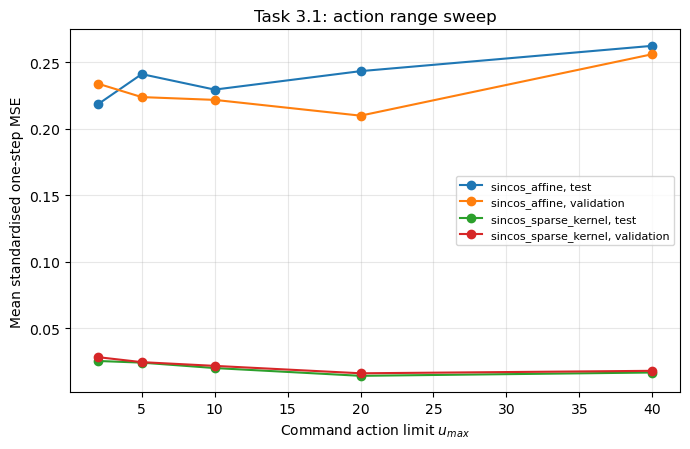

In [14]:

# Plot validation/test standardised MSE vs action limit.
plot_df = sweep_df[(sweep_df["split"].isin(["validation", "test"]))]
fig, ax = plt.subplots(figsize=(7.0, 4.6))
for (model, split), g in plot_df.groupby(["model", "split"]):
    g = g.sort_values("action_limit")
    ax.plot(g["action_limit"], g["std_mse_mean"], marker="o", label=f"{model}, {split}")
ax.set_xlabel("Command action limit $u_{max}$")
ax.set_ylabel("Mean standardised one-step MSE")
ax.set_title("Task 3.1: action range sweep")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "task31_action_range_sweep_std_mse.png", dpi=220)
plt.show()



### Working action limit for the rest of the notebook

The rest of this notebook uses `SELECTED_ACTION_LIMIT = 20.0` by default.  This is a conservative command range because it covers substantial control authority while avoiding the strongest saturation region near \(\pm 40\).  After a full run, this choice should be justified using the sweep table above.


In [16]:

A_SELECT = float(SELECTED_ACTION_LIMIT)

if A_SELECT in sweep_bundles:
    final_bundle = sweep_bundles[A_SELECT]
else:
    _, final_bundle = fit_and_evaluate_for_action_limit(A_SELECT, SEED + 2000)

X_train, Y_train = final_bundle["X_train"], final_bundle["Y_train"]
X_val, Y_val = final_bundle["X_val"], final_bundle["Y_val"]
X_test, Y_test = final_bundle["X_test"], final_bundle["Y_test"]
linear_model = final_bundle["linear_model"]
kernel_model = final_bundle["kernel_model"]

selected_metrics = sweep_df[(sweep_df["action_limit"] == A_SELECT) & (sweep_df["split"].isin(["validation", "test"]))]
display(selected_metrics[summary_cols])

np.savez(
    DATA_DIR / "selected_action_dataset.npz",
    X_train=X_train, Y_train=Y_train,
    X_val=X_val, Y_val=Y_val,
    X_test=X_test, Y_test=Y_test,
)


,action_limit,effective_force_at_limit,split,model,std_mse_mean,std_mse_delta_x,std_mse_delta_x_dot,std_mse_delta_theta,std_mse_delta_theta_dot
20,20.0,15.231883,validation,sincos_affine,0.209955,0.003977,0.242501,0.028784,0.564559
21,20.0,15.231883,validation,sincos_sparse_kernel,0.016061,0.000308,0.038344,0.001327,0.024263
22,20.0,15.231883,test,sincos_affine,0.243461,0.004061,0.242207,0.034848,0.692729
23,20.0,15.231883,test,sincos_sparse_kernel,0.014157,0.000250,0.031660,0.001440,0.023276



## 6. Component-wise prediction accuracy

This table fixes one of the issues in the interim report: when we say "MSE", we must specify **which state component** it refers to.  The standardised MSE is more useful for comparing components because $\Delta\dot{\theta}$ naturally has a much larger numerical scale than $\Delta x$.


,split,model,component,raw_mse,standardised_mse
0,train,sincos_affine,delta_x,0.001304,0.003863
1,train,sincos_affine,delta_x_dot,0.530883,0.236354
2,train,sincos_affine,delta_theta,0.026625,0.032748
3,train,sincos_affine,delta_theta_dot,9.809514,0.656781
4,train,sincos_sparse_kernel,delta_x,0.000071,0.000209
5,train,sincos_sparse_kernel,delta_x_dot,0.061637,0.027441
6,train,sincos_sparse_kernel,delta_theta,0.000880,0.001082
7,train,sincos_sparse_kernel,delta_theta_dot,0.299907,0.020080
8,validation,sincos_affine,delta_x,0.001342,0.003977
9,validation,sincos_affine,delta_x_dot,0.544690,0.242501


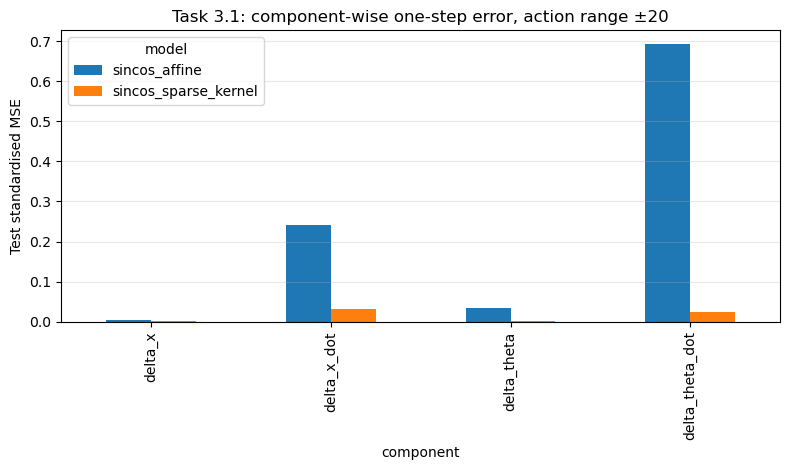

In [18]:

component_rows = []
for split, X, Y in [("train", X_train, Y_train), ("validation", X_val, Y_val), ("test", X_test, Y_test)]:
    for label, model in [("sincos_affine", linear_model), ("sincos_sparse_kernel", kernel_model)]:
        pred = model.predict_delta(X)
        err = pred - Y
        raw_mse = np.mean(err**2, axis=0)
        std_mse = np.mean((err / model.y_scale)**2, axis=0)
        for comp, rm, sm in zip(DELTA_NAMES, raw_mse, std_mse):
            component_rows.append({
                "split": split,
                "model": label,
                "component": comp,
                "raw_mse": float(rm),
                "standardised_mse": float(sm),
            })
component_df = pd.DataFrame(component_rows)
component_df.to_csv(LOG_DIR / "selected_action_component_mse.csv", index=False)
display(component_df)

# Bar chart for report/notebook checking
fig, ax = plt.subplots(figsize=(8.0, 4.8))
test_component = component_df[component_df["split"] == "test"].copy()
pivot = test_component.pivot(index="component", columns="model", values="standardised_mse").loc[DELTA_NAMES]
pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("Test standardised MSE")
ax.set_title(f"Task 3.1: component-wise one-step error, action range ±{A_SELECT:g}")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "task31_componentwise_test_mse.png", dpi=220)
plt.show()



## 7. Scatter plot: target vs prediction

Each panel is one component of $\Delta X$.  A perfect model would lie on the diagonal.  This is a compact way to verify that the action-conditioned model is learning the one-step dynamics rather than only matching aggregate MSE.


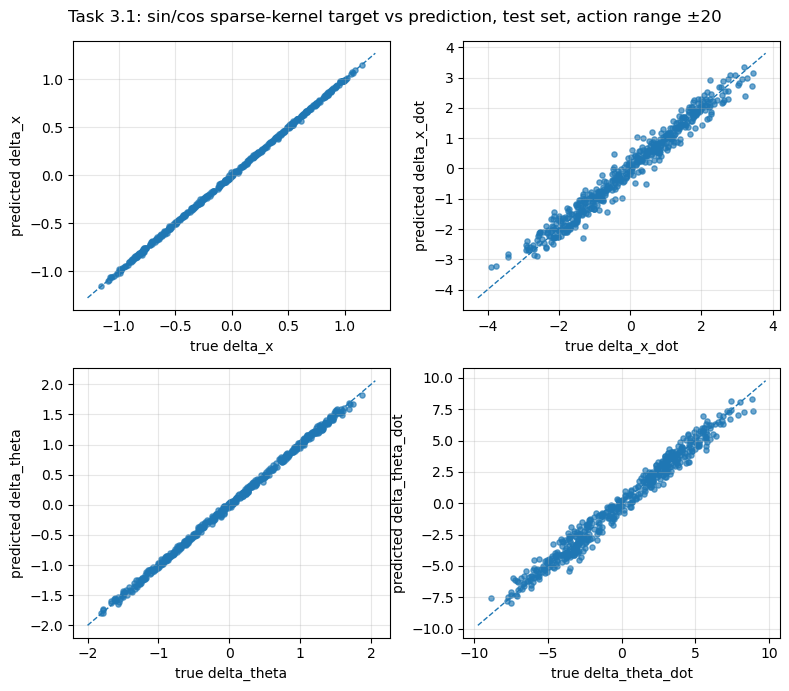

In [20]:

def plot_target_vs_prediction(model, X: np.ndarray, Y: np.ndarray, filename: str, title: str):
    pred = model.predict_delta(X)
    fig, axes = plt.subplots(2, 2, figsize=(8.0, 7.0))
    axes = axes.ravel()
    for j, ax in enumerate(axes):
        ax.scatter(Y[:, j], pred[:, j], s=14, alpha=0.65)
        lo = min(np.min(Y[:, j]), np.min(pred[:, j]))
        hi = max(np.max(Y[:, j]), np.max(pred[:, j]))
        pad = 0.05 * (hi - lo + 1e-12)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], linestyle="--", linewidth=1)
        ax.set_xlabel(f"true {DELTA_NAMES[j]}")
        ax.set_ylabel(f"predicted {DELTA_NAMES[j]}")
        ax.grid(True, alpha=0.3)
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(FIG_DIR / filename, dpi=220)
    plt.show()

plot_target_vs_prediction(
    kernel_model,
    X_test,
    Y_test,
    "task31_kernel_target_vs_prediction_test.png",
    f"Task 3.1: sin/cos sparse-kernel target vs prediction, test set, action range ±{A_SELECT:g}",
)



## 8. 1D action scan

Here we fix the state and vary only the action.  This checks that the model has learned the action dependence locally.

The two most action-sensitive components are usually $\Delta\dot{x}$ and $\Delta\dot{\theta}$, so those are plotted separately instead of squeezing all four components into a tiny figure.


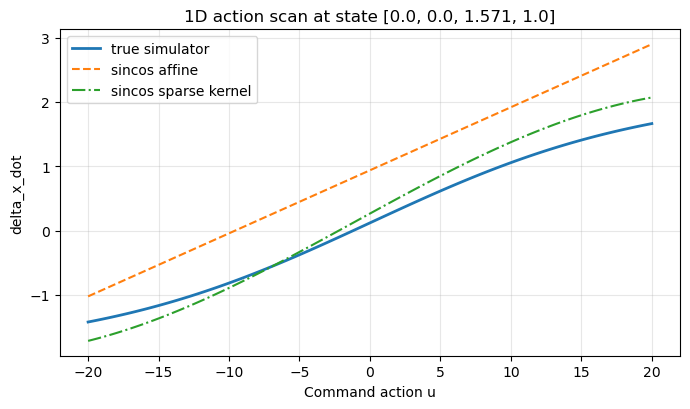

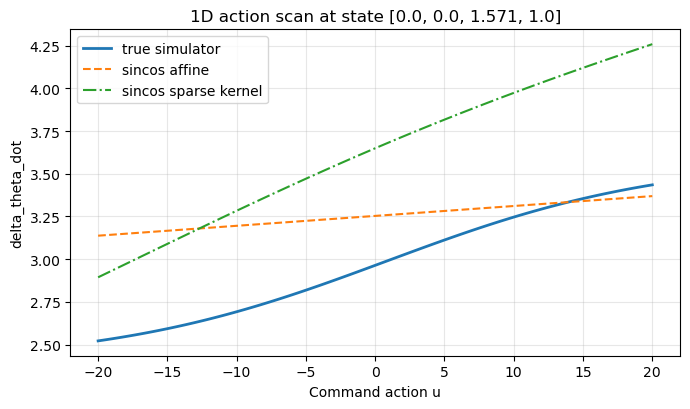

In [22]:

def make_X5_from_state_action_grid(state: np.ndarray, actions: np.ndarray) -> np.ndarray:
    states = np.repeat(np.asarray(state, dtype=float)[None, :], len(actions), axis=0)
    return np.column_stack([states, actions])

scan_state = np.array([0.0, 0.0, 0.5 * np.pi, 1.0])
actions = np.linspace(-A_SELECT, A_SELECT, 121 if RUN_MODE == "full" else 241)
X_scan = make_X5_from_state_action_grid(scan_state, actions)
Y_true_scan = np.array([one_step_delta(scan_state, u) for u in actions])
Y_lin_scan = linear_model.predict_delta(X_scan)
Y_ker_scan = kernel_model.predict_delta(X_scan)

for comp_idx, comp_name in [(1, "delta_x_dot"), (3, "delta_theta_dot")]:
    fig, ax = plt.subplots(figsize=(7.0, 4.2))
    ax.plot(actions, Y_true_scan[:, comp_idx], label="true simulator", linewidth=2)
    ax.plot(actions, Y_lin_scan[:, comp_idx], label="sincos affine", linestyle="--")
    ax.plot(actions, Y_ker_scan[:, comp_idx], label="sincos sparse kernel", linestyle="-.")
    ax.set_xlabel("Command action u")
    ax.set_ylabel(comp_name)
    ax.set_title(f"1D action scan at state {np.round(scan_state, 3).tolist()}")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"task31_1d_action_scan_{comp_name}.png", dpi=220)
    plt.show()



## 9. 2D scan: angle-action slice

This plot checks whether the model captures the interaction between pole angle and action.  The third panel is an error map with a divergent colour scale centred on zero, which is clearer for signed residuals.


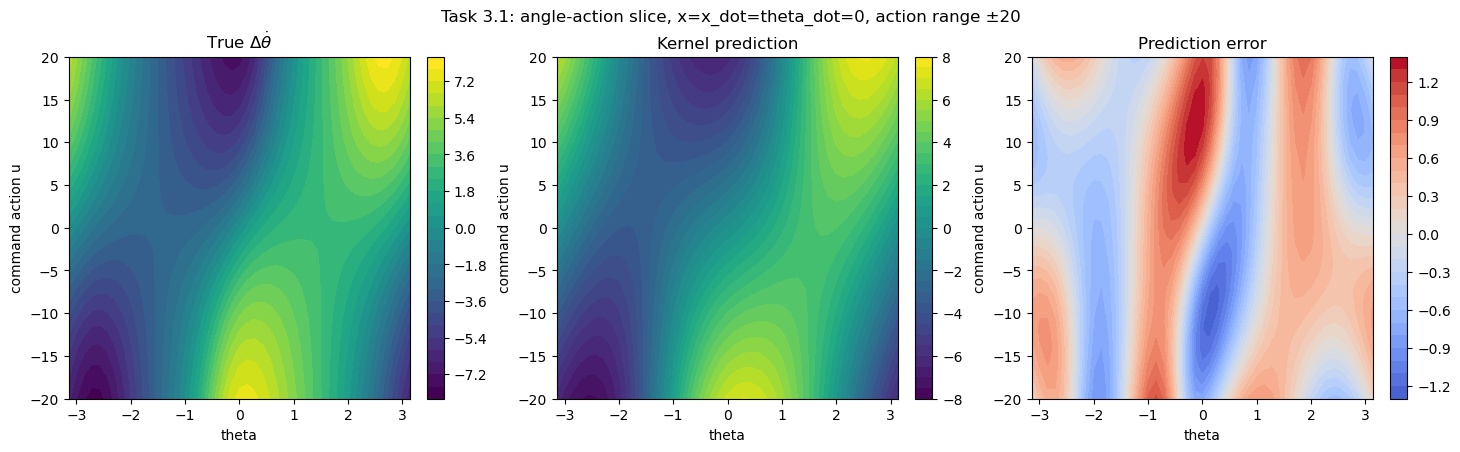

In [24]:

from matplotlib.colors import TwoSlopeNorm


theta_vals = np.linspace(-np.pi, np.pi, GRID_N)
action_vals = np.linspace(-A_SELECT, A_SELECT, GRID_N)
Theta, U = np.meshgrid(theta_vals, action_vals, indexing="xy")
base = np.zeros((Theta.size, 4))
base[:, 0] = 0.0       # x
base[:, 1] = 0.0       # x_dot
base[:, 2] = Theta.ravel()
base[:, 3] = 0.0       # theta_dot
X_grid = np.column_stack([base, U.ravel()])
Y_true_grid = np.array([one_step_delta(s, u) for s, u in zip(base, U.ravel())])
Y_pred_grid = kernel_model.predict_delta(X_grid)

component_idx = 3  # delta_theta_dot
true_map = Y_true_grid[:, component_idx].reshape(GRID_N, GRID_N)
pred_map = Y_pred_grid[:, component_idx].reshape(GRID_N, GRID_N)
err_map = pred_map - true_map

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2), constrained_layout=True)
levels = 31
vmin = min(true_map.min(), pred_map.min())
vmax = max(true_map.max(), pred_map.max())

im0 = axes[0].contourf(Theta, U, true_map, levels=levels, vmin=vmin, vmax=vmax)
axes[0].set_title("True $\\Delta\\dot{\\theta}$")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(Theta, U, pred_map, levels=levels, vmin=vmin, vmax=vmax)
axes[1].set_title("Kernel prediction")
fig.colorbar(im1, ax=axes[1])

max_abs_err = float(np.max(np.abs(err_map))) + 1e-12
norm = TwoSlopeNorm(vmin=-max_abs_err, vcenter=0.0, vmax=max_abs_err)
im2 = axes[2].contourf(Theta, U, err_map, levels=levels, norm=norm, cmap="coolwarm")
axes[2].set_title("Prediction error")
fig.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xlabel("theta")
    ax.set_ylabel("command action u")

fig.suptitle(f"Task 3.1: angle-action slice, x=x_dot=theta_dot=0, action range ±{A_SELECT:g}", y=1.04)
fig.savefig(FIG_DIR / "task31_2d_theta_action_delta_theta_dot.png", dpi=220, bbox_inches="tight")
plt.show()



## 10. Open-loop rollout under a known action sequence

This is still **not policy optimisation**.  We use a fixed sequence of actions and compare:

1. true CartPole rollout under those actions;
2. affine model rollout under the same actions;
3. sparse-kernel model rollout under the same actions.

This tests whether one-step accuracy survives recursive use when actions are included.


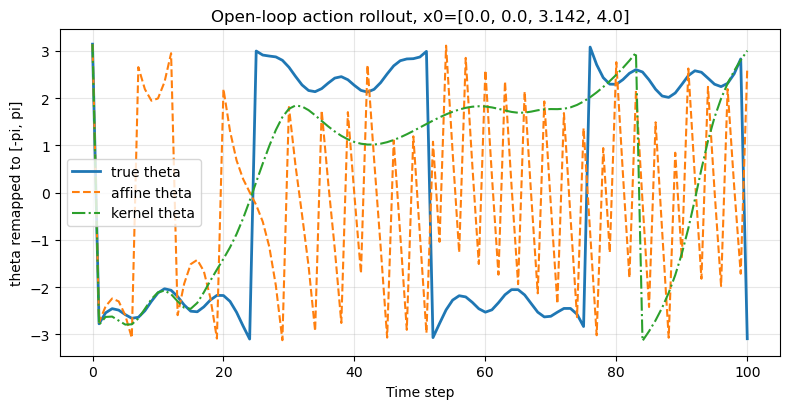

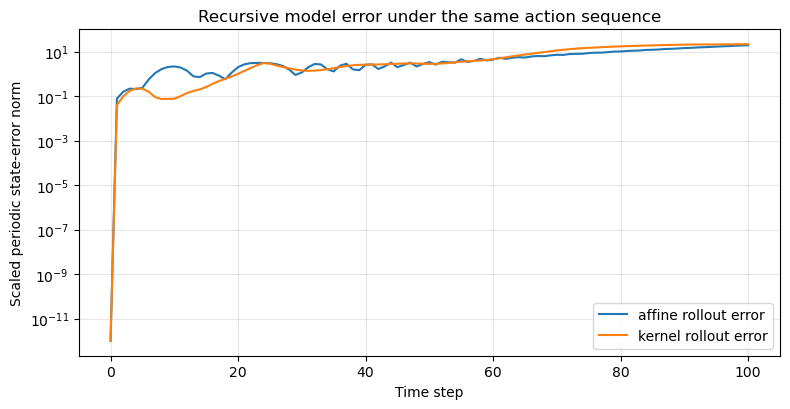

,model,final_error_norm,median_error_norm,max_error_norm
0,sincos_affine,19.516152,3.219389,19.516152
1,sincos_sparse_kernel,21.783517,2.951176,21.783517


In [26]:

def true_rollout(x0: np.ndarray, actions: np.ndarray) -> np.ndarray:
    system = CartPole(visual=False)
    system.setState(np.asarray(x0, dtype=float).copy())
    states = [system.getState().copy()]
    for u in actions:
        system.performAction(float(u))
        states.append(system.getState().copy())
    return np.array(states)


def model_rollout(model, x0: np.ndarray, actions: np.ndarray) -> np.ndarray:
    x = np.asarray(x0, dtype=float).copy()
    states = [x.copy()]
    for u in actions:
        X5 = np.array([[x[0], x[1], x[2], x[3], float(u)]])
        dx = model.predict_delta(X5)[0]
        x = x + dx
        states.append(x.copy())
    return np.array(states)


def state_error_norm(pred_states: np.ndarray, true_states: np.ndarray) -> np.ndarray:
    err = pred_states - true_states
    err[:, 2] = periodic_angle_error(pred_states[:, 2], true_states[:, 2])
    # Scale velocities so one large velocity unit does not dominate the norm too strongly.
    scale = np.array([5.0, 10.0, 1.0, 15.0])
    return np.linalg.norm(err / scale, axis=1)


T = ROLLOUT_HORIZON
t = np.arange(T)
# A smooth open-loop action sequence, inside the selected training action range.
action_sequence = 0.65 * A_SELECT * np.sin(2 * np.pi * t / max(20, T // 2))
rollout_x0 = np.array([0.0, 0.0, np.pi, 4.0])

true_states = true_rollout(rollout_x0, action_sequence)
lin_states = model_rollout(linear_model, rollout_x0, action_sequence)
ker_states = model_rollout(kernel_model, rollout_x0, action_sequence)

lin_err = state_error_norm(lin_states, true_states)
ker_err = state_error_norm(ker_states, true_states)

# Save rollout arrays.
np.savez(
    DATA_DIR / "task31_open_loop_rollout.npz",
    x0=rollout_x0,
    actions=action_sequence,
    true_states=true_states,
    linear_states=lin_states,
    kernel_states=ker_states,
    linear_error_norm=lin_err,
    kernel_error_norm=ker_err,
)

fig, ax = plt.subplots(figsize=(8.0, 4.2))
steps = np.arange(T + 1)
ax.plot(steps, [remap_angle(v) for v in true_states[:, 2]], label="true theta", linewidth=2)
ax.plot(steps, [remap_angle(v) for v in lin_states[:, 2]], label="affine theta", linestyle="--")
ax.plot(steps, [remap_angle(v) for v in ker_states[:, 2]], label="kernel theta", linestyle="-.")
ax.set_xlabel("Time step")
ax.set_ylabel("theta remapped to [-pi, pi]")
ax.set_title(f"Open-loop action rollout, x0={np.round(rollout_x0, 3).tolist()}")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "task31_open_loop_rollout_theta.png", dpi=220)
plt.show()

fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.semilogy(steps, lin_err + 1e-12, label="affine rollout error")
ax.semilogy(steps, ker_err + 1e-12, label="kernel rollout error")
ax.set_xlabel("Time step")
ax.set_ylabel("Scaled periodic state-error norm")
ax.set_title("Recursive model error under the same action sequence")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "task31_open_loop_rollout_error.png", dpi=220)
plt.show()

rollout_summary = pd.DataFrame({
    "model": ["sincos_affine", "sincos_sparse_kernel"],
    "final_error_norm": [float(lin_err[-1]), float(ker_err[-1])],
    "median_error_norm": [float(np.median(lin_err)), float(np.median(ker_err))],
    "max_error_norm": [float(np.max(lin_err)), float(np.max(ker_err))],
})
display(rollout_summary)
rollout_summary.to_csv(LOG_DIR / "task31_open_loop_rollout_summary.csv", index=False)



## 11. Stress test by action-magnitude bin

The previous sweep trains and tests on the same action range.  This stress test trains on \(\pm u_{\max}\) but evaluates separate bins, including a bin beyond the selected training range.  This is the most direct evidence for the final report sentence:

> The model remains accurate up to approximately \(\pm ...\) commanded action / \(\pm ...\) effective force, but becomes less reliable when extrapolating beyond that range.


,action_abs_bin,inside_training_action_range,model,std_mse_mean,std_mse_delta_x,std_mse_delta_x_dot,std_mse_delta_theta,std_mse_delta_theta_dot,effective_force_lo,effective_force_hi
0,"[0, 5]",True,sincos_affine,0.106222,0.003254,0.197155,0.010407,0.214074,0.000000,4.898373
1,"[0, 5]",True,sincos_sparse_kernel,0.011653,0.000189,0.025893,0.001203,0.019327,0.000000,4.898373
2,"[5, 10]",True,sincos_affine,0.176880,0.003668,0.229468,0.021548,0.452838,4.898373,9.242343
3,"[5, 10]",True,sincos_sparse_kernel,0.011826,0.000198,0.024099,0.001317,0.021691,4.898373,9.242343
4,"[10, 20]",True,sincos_affine,0.306880,0.003935,0.256117,0.045050,0.922417,9.242343,15.231883
5,"[10, 20]",True,sincos_sparse_kernel,0.015699,0.000299,0.035952,0.001564,0.024979,9.242343,15.231883
6,"[20, 40]",False,sincos_affine,0.631248,0.012307,0.690019,0.087166,1.735501,15.231883,19.280552
7,"[20, 40]",False,sincos_sparse_kernel,0.089478,0.003837,0.223494,0.006227,0.124356,15.231883,19.280552


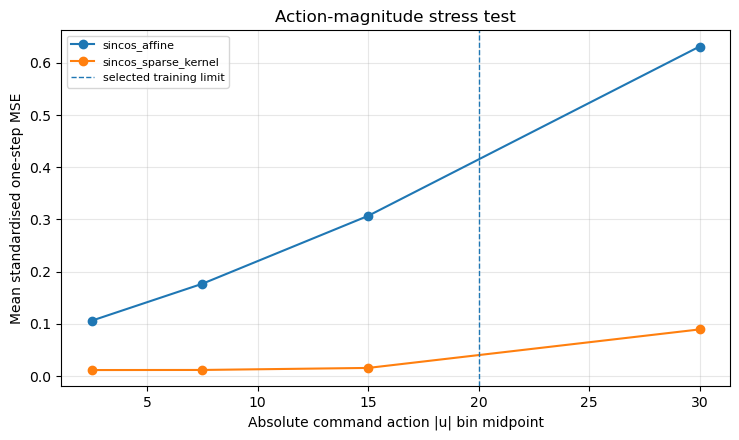

In [28]:

def sample_action_bin_dataset(n: int, lo: float, hi: float, rng: np.random.Generator) -> Tuple[np.ndarray, np.ndarray]:
    states = sample_states(n, rng)
    signs = rng.choice([-1.0, 1.0], size=n)
    magnitudes = rng.uniform(lo, hi, size=n)
    actions = signs * magnitudes
    X5 = np.column_stack([states, actions])
    Y = np.empty((n, 4), dtype=float)
    for i in range(n):
        Y[i] = one_step_delta(states[i], actions[i])
    return X5, Y


action_bins = [(0.0, 5.0), (5.0, 10.0), (10.0, 20.0), (20.0, 40.0)]
bin_rows = []
bin_rng = np.random.default_rng(SEED + 3000)
for lo, hi in action_bins:
    X_bin, Y_bin = sample_action_bin_dataset(BIN_N, lo, hi, bin_rng)
    for label, model in [("sincos_affine", linear_model), ("sincos_sparse_kernel", kernel_model)]:
        row = evaluate_model(model, X_bin, Y_bin, label)
        row.update({
            "action_abs_bin": f"[{lo:g}, {hi:g}]",
            "action_abs_lo": lo,
            "action_abs_hi": hi,
            "effective_force_lo": float(abs(effective_force(lo))),
            "effective_force_hi": float(abs(effective_force(hi))),
            "inside_training_action_range": bool(hi <= A_SELECT),
        })
        bin_rows.append(row)

bin_df = pd.DataFrame(bin_rows)
bin_df.to_csv(LOG_DIR / "task31_action_bin_stress_test.csv", index=False)
display(bin_df[[
    "action_abs_bin", "inside_training_action_range", "model", "std_mse_mean",
    "std_mse_delta_x", "std_mse_delta_x_dot", "std_mse_delta_theta", "std_mse_delta_theta_dot",
    "effective_force_lo", "effective_force_hi"
]])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for model, g in bin_df.groupby("model"):
    g = g.sort_values("action_abs_lo")
    mids = 0.5 * (g["action_abs_lo"].to_numpy() + g["action_abs_hi"].to_numpy())
    ax.plot(mids, g["std_mse_mean"], marker="o", label=model)
ax.axvline(A_SELECT, linestyle="--", linewidth=1, label="selected training limit")
ax.set_xlabel("Absolute command action |u| bin midpoint")
ax.set_ylabel("Mean standardised one-step MSE")
ax.set_title("Action-magnitude stress test")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "task31_action_bin_stress_test.png", dpi=220)
plt.show()



## 12. Report-ready notes and next step

Run the cell below after checking the plots.  It writes a short markdown note to `logs/task31_report_notes.md`.  The numbers are placeholders filled from this run; when switching to `RUN_MODE="full"`, regenerate the notes before using them in the final report.


In [30]:

# Extract a compact report summary from current run.
ker_test = sweep_df[
    (sweep_df["split"] == "test") &
    (sweep_df["model"] == "sincos_sparse_kernel")
].sort_values("action_limit")

selected_test = ker_test[ker_test["action_limit"] == A_SELECT].iloc[0]
selected_force = float(abs(effective_force(A_SELECT)))

# Check extrapolation bin if present.
ker_bins = bin_df[bin_df["model"] == "sincos_sparse_kernel"].sort_values("action_abs_lo")
inside = ker_bins[ker_bins["inside_training_action_range"]]
outside = ker_bins[~ker_bins["inside_training_action_range"]]
inside_last = inside.iloc[-1] if len(inside) else None
outside_first = outside.iloc[0] if len(outside) else None

notes = []
notes.append("# Task 3.1 report notes\n")
notes.append(f"Run mode: `{RUN_MODE}`. Use full-run values in the final report.\n")
notes.append(f"Selected command action range: ±{A_SELECT:g}. This corresponds to approximately ±{selected_force:.3g} N after tanh saturation with max_force=20.\n")
notes.append(f"Sparse-kernel test mean standardised MSE at this range: {selected_test['std_mse_mean']:.4g}.\n")
notes.append("The model input was `[x, x_dot, sin(theta), cos(theta), theta_dot, action]`, i.e. the physical 5-variable state-action input with periodic angle represented by sine and cosine.\n")
notes.append("The sparse-kernel model was fitted with centres selected from the training data and a multi-output solve; this is equivalent to four independent output models sharing centres and kernel hyperparameters.\n")
if inside_last is not None:
    notes.append(f"Largest tested action bin inside the selected training range: {inside_last['action_abs_bin']}; kernel standardised MSE = {inside_last['std_mse_mean']:.4g}.\n")
if outside_first is not None:
    notes.append(f"First extrapolation bin beyond the selected training range: {outside_first['action_abs_bin']}; kernel standardised MSE = {outside_first['std_mse_mean']:.4g}.\n")
notes.append("Suggested final-report claim: action-conditioned one-step prediction is reliable inside the sampled action range, but the stress-test bin beyond the training range should be treated as extrapolation, especially because large actions lie near the tanh saturation region.\n")
notes.append("Next notebook: optimise a linear feedback policy on the true CartPole dynamics, then compare with model-based optimisation over a short horizon.\n")

notes_text = "\n".join(notes)
print(notes_text)
with open(LOG_DIR / "task31_report_notes.md", "w") as f:
    f.write(notes_text)


# Task 3.1 report notes

Run mode: `full`. Use full-run values in the final report.

Selected command action range: ±20. This corresponds to approximately ±15.2 N after tanh saturation with max_force=20.

Sparse-kernel test mean standardised MSE at this range: 0.01416.

The model input was `[x, x_dot, sin(theta), cos(theta), theta_dot, action]`, i.e. the physical 5-variable state-action input with periodic angle represented by sine and cosine.

The sparse-kernel model was fitted with centres selected from the training data and a multi-output solve; this is equivalent to four independent output models sharing centres and kernel hyperparameters.

Largest tested action bin inside the selected training range: [10, 20]; kernel standardised MSE = 0.0157.

First extrapolation bin beyond the selected training range: [20, 40]; kernel standardised MSE = 0.08948.

Suggested final-report claim: action-conditioned one-step prediction is reliable inside the sampled action range, but the stress-test 


# End of Week 3.1 notebook

Before moving to policy search, check these files:

```text
sf3_week3_task31_action_model/logs/action_range_sweep_metrics.csv
sf3_week3_task31_action_model/logs/selected_action_component_mse.csv
sf3_week3_task31_action_model/logs/task31_action_bin_stress_test.csv
sf3_week3_task31_action_model/figures/task31_action_range_sweep_std_mse.png
sf3_week3_task31_action_model/figures/task31_componentwise_test_mse.png
sf3_week3_task31_action_model/figures/task31_open_loop_rollout_error.png
```

If these look sensible, move on to **Task 3.2: true-dynamics linear policy search**.
